   LOSO RESULTS SUMMARY: T6_noPT_uniform

[Mean per-user weighted F1]
 → 0.6385379231403517

[All data weighted F1]
 → 0.652850816838214

[Per-user detail]
  U0101: 0.7058
  U0102: 0.6711
  U0103: 0.6944
  U0104: 0.6627
  U0105: 0.6941
  U0106: 0.7133
  U0107: 0.6856
  U0108: 0.6776
  U0109: 0.4828
  U0110: 0.3980


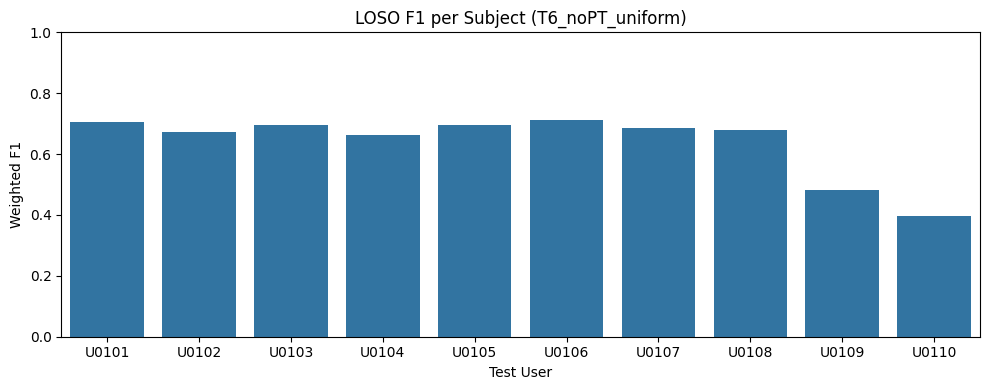

In [2]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# === 読み込み対象ディレクトリ ===
results_dir = "results_loso/seed0/T6_noPT_uniform"

# === ファイル一覧 ===
files = sorted(os.listdir(results_dir))

# === 結果格納 ===
f1_per_user = {}
all_y = []
all_p = []

# === 各ファイルの読み込み ===
for fname in files:
    if not fname.endswith(".json"):
        continue

    path = os.path.join(results_dir, fname)
    with open(path, "r") as fp:
        res = json.load(fp)

    user = res["user"]
    y_true = np.array(res["y_true"])
    y_pred = np.array(res["y_pred"])

    # weighted F1
    f1_u = f1_score(y_true, y_pred, average="weighted")
    f1_per_user[user] = f1_u

    # 全体評価用
    all_y.extend(y_true)
    all_p.extend(y_pred)

# === 全体 weighted F1 ===
all_y = np.array(all_y)
all_p = np.array(all_p)
f1_all_weighted = f1_score(all_y, all_p, average="weighted")

# ==== 出力 ====
print("============================================")
print("   LOSO RESULTS SUMMARY: T6_noPT_uniform")
print("============================================")
print("\n[Mean per-user weighted F1]")
print(" →", np.mean(list(f1_per_user.values())))

print("\n[All data weighted F1]")
print(" →", f1_all_weighted)

print("\n[Per-user detail]")
for u, score in f1_per_user.items():
    print(f"  {u}: {score:.4f}")

# ==== プロット ====
plt.figure(figsize=(10, 4))
sns.barplot(x=list(f1_per_user.keys()), y=list(f1_per_user.values()))
plt.ylim(0, 1)
plt.xlabel("Test User")
plt.ylabel("Weighted F1")
plt.title("LOSO F1 per Subject (T6_noPT_uniform)")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.stats import mode

def smooth_majority(y, k=5):
    half = k // 2
    y_smooth = np.copy(y)

    for i in range(len(y)):
        l = max(0, i - half)
        r = min(len(y), i + half + 1)
        y_smooth[i] = mode(y[l:r], keepdims=False).mode

    return y_smooth


     User    F1_raw  F1_smooth
0   U0101  0.705813   0.576879
1   U0102  0.671139   0.612931
2   U0103  0.694352   0.569337
3   U0104  0.662667   0.619226
4   U0105  0.694063   0.603364
5   U0106  0.713261   0.673562
6   U0107  0.685623   0.585866
7   U0108  0.677606   0.566720
8   U0109  0.482813   0.467983
9   U0110  0.398044   0.301981
10   Mean  0.638538   0.557785


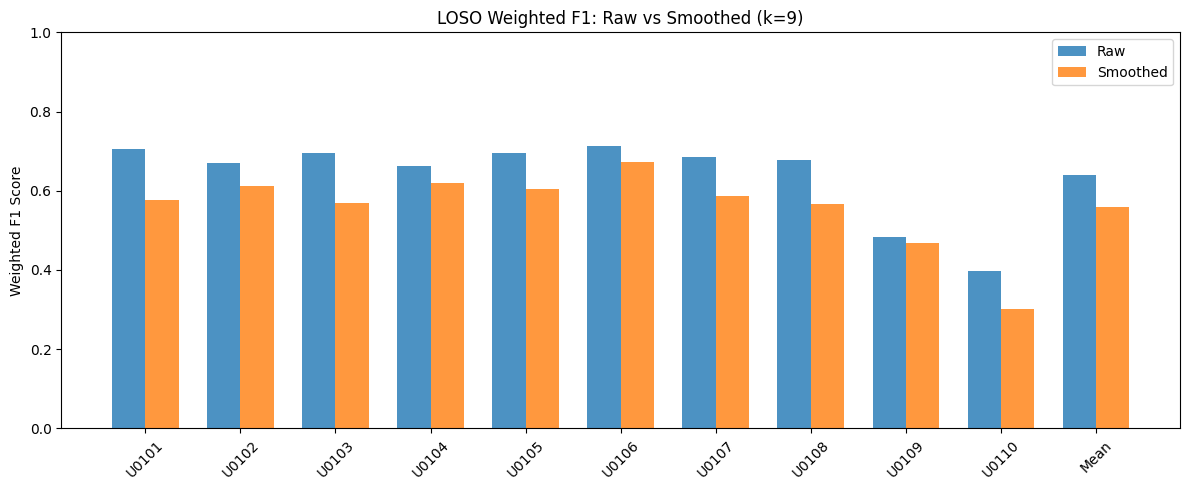

In [40]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==== 平滑化関数：移動多数決 ====
def smooth_majority(y, k=1):
    y = np.asarray(y)
    out = y.copy()

    left = k // 2
    right = k - left - 1

    n = len(y)

    for i in range(n):
        l = max(0, i - left)
        r = min(n, i + right + 1)   # +1 because slice is exclusive
        segment = y[l:r]

        out[i] = np.bincount(segment).argmax()

    return out

# ==== 結果ディレクトリ ====
results_dir = "results_loso/seed0/T6_noPT_uniform"
files = sorted(os.listdir(results_dir))

rows = []

for fname in files:
    if not fname.endswith(".json"):
        continue

    with open(os.path.join(results_dir, fname)) as fp:
        res = json.load(fp)

    user = res["user"]
    y_true = np.array(res["y_true"])
    y_pred = np.array(res["y_pred"])

    # 平滑化
    y_pred_smooth = smooth_majority(y_pred, k=5)

    # F1 計算
    f1_raw = f1_score(y_true, y_pred, average="weighted")
    f1_smooth = f1_score(y_true, y_pred_smooth, average="weighted")

    rows.append([user, f1_raw, f1_smooth])

# ==== DataFrame ====
df = pd.DataFrame(rows, columns=["User", "F1_raw", "F1_smooth"])

# ==== 平均行 ====
df.loc[len(df)] = ["Mean", df["F1_raw"].mean(), df["F1_smooth"].mean()]

print(df)

# ======================================
#           📊 プロット部分
# ======================================
plt.figure(figsize=(12, 5))

x = np.arange(len(df["User"]))
width = 0.35

plt.bar(x - width/2, df["F1_raw"], width=width, label="Raw", alpha=0.8)
plt.bar(x + width/2, df["F1_smooth"], width=width, label="Smoothed", alpha=0.8)

plt.xticks(x, df["User"], rotation=45)
plt.ylim(0, 1)
plt.ylabel("Weighted F1 Score")
plt.title("LOSO Weighted F1: Raw vs Smoothed (k=9)")
plt.legend()

plt.tight_layout()
plt.show()


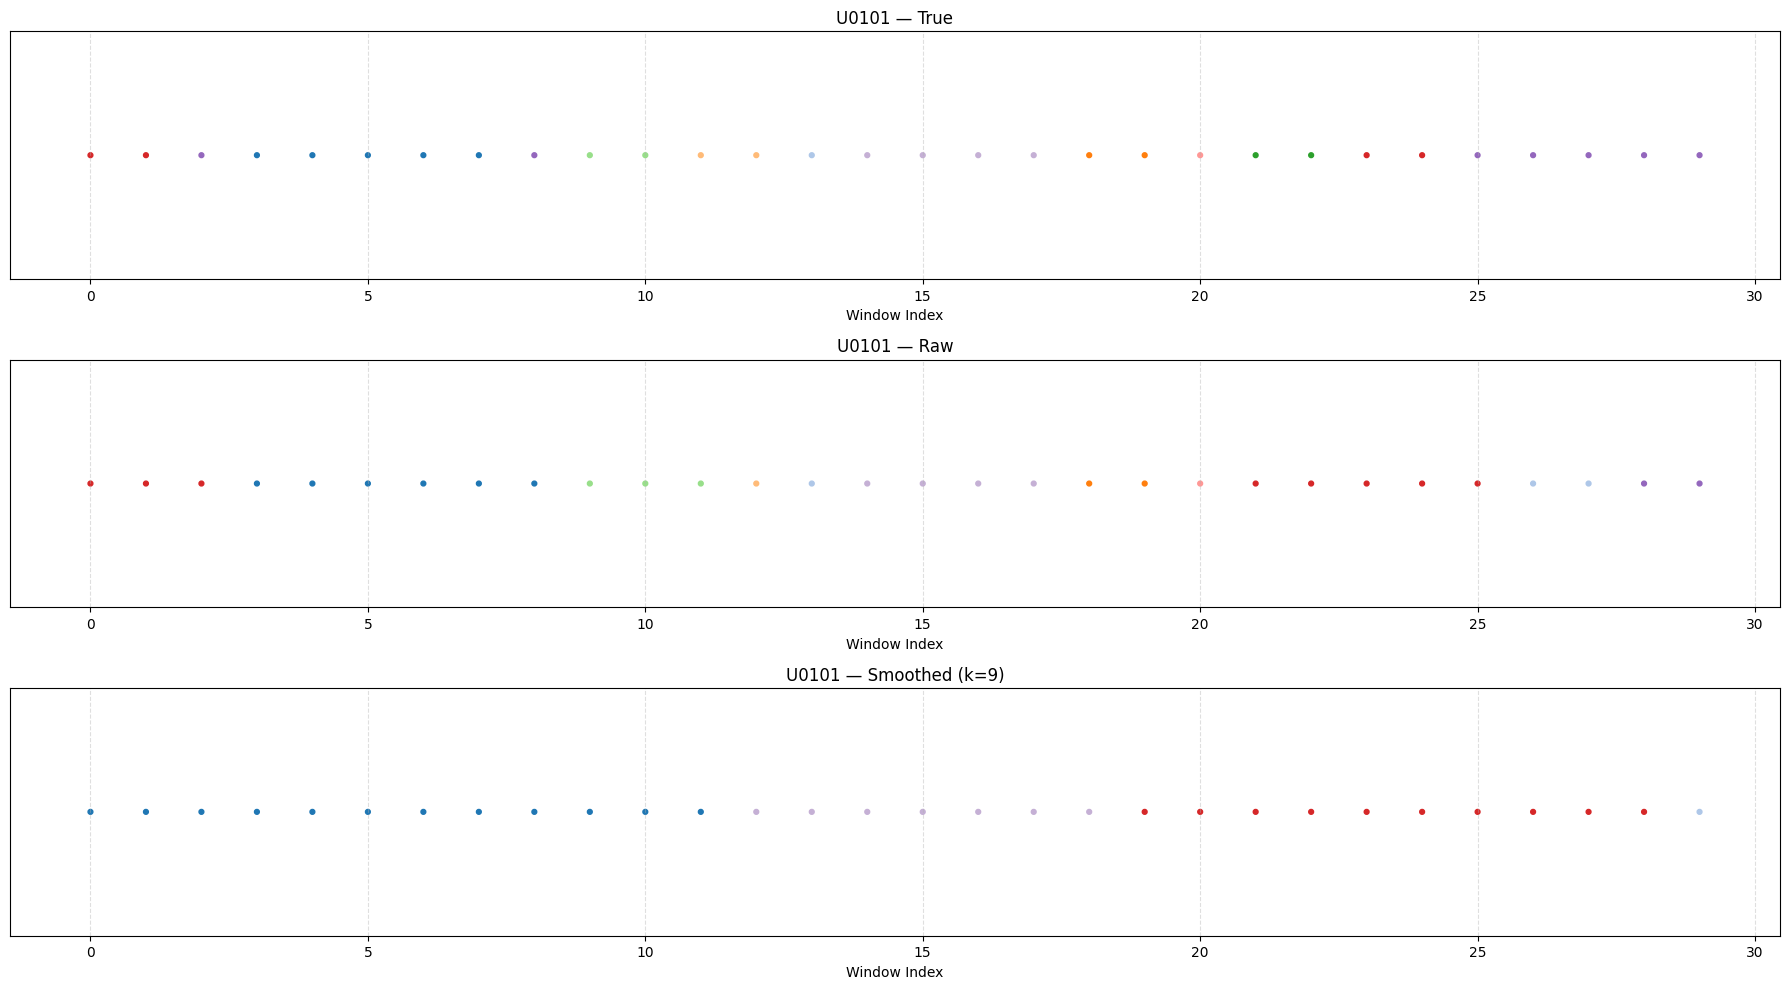

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# ==== smoothing ====
def smooth_majority(y, k=3):
    half = k // 2
    out = y.copy()
    for i in range(len(y)):
        l = max(0, i-half)
        r = min(len(y), i+half+1)
        out[i] = np.bincount(y[l:r]).argmax()
    return out


# ==== 対象ユーザ ====
target_user = "U0101"
results_dir = "results_loso/seed0/T6_noPT_uniform"

# ==== 読み込み ====
with open(os.path.join(results_dir, f"{target_user}.json")) as fp:
    res = json.load(fp)

y_true = np.array(res["y_true"])[:30]
y_pred = np.array(res["y_pred"])[:30]
y_pred_smooth = smooth_majority(y_pred, k=10)[:30]

# y_true, y_pred, y_pred_smooth が 11分類のラベル（int）だと仮定

# === 出現する全ラベルを取得 ===
unique_labels = np.unique(
    np.concatenate([y_true, y_pred, y_pred_smooth])
)
unique_labels = np.sort(unique_labels)

# === tab20 からラベルごとに色を割り当てる ===
cmap = plt.get_cmap("tab20")
tab_colors = {lab: cmap(i % 20) for i, lab in enumerate(unique_labels)}

def color_by_label(y):
    return [tab_colors[int(v)] for v in y]

colors_true   = color_by_label(y_true)
colors_raw    = color_by_label(y_pred)
colors_smooth = color_by_label(y_pred_smooth)


y_true


# === 横に3つ並べる ===
plt.figure(figsize=(18, 10))

# -------------- 1. Ground Truth --------------
plt.subplot(3,1,1)
plt.scatter(
    np.arange(len(y_true)),
    np.zeros_like(y_true),      # y=0 の一列に並べる
    c=colors_true, s=12
)
plt.title(f"{target_user} — True")
plt.yticks([])
plt.xlabel("Window Index")
plt.grid(axis='x', linestyle='--', alpha=0.4)


# -------------- 2. Raw Prediction --------------
plt.subplot(3,1,2)
plt.scatter(
    np.arange(len(y_pred)),
    np.zeros_like(y_pred),
    c=colors_raw, s=12
)
plt.title(f"{target_user} — Raw")
plt.yticks([])
plt.xlabel("Window Index")
plt.grid(axis='x', linestyle='--', alpha=0.4)


# -------------- 3. Smoothed Prediction --------------
plt.subplot(3,1,3)
plt.scatter(
    np.arange(len(y_pred_smooth)),
    np.zeros_like(y_pred_smooth),
    c=colors_smooth, s=12
)
plt.title(f"{target_user} — Smoothed (k=9)")
plt.yticks([])
plt.xlabel("Window Index")
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


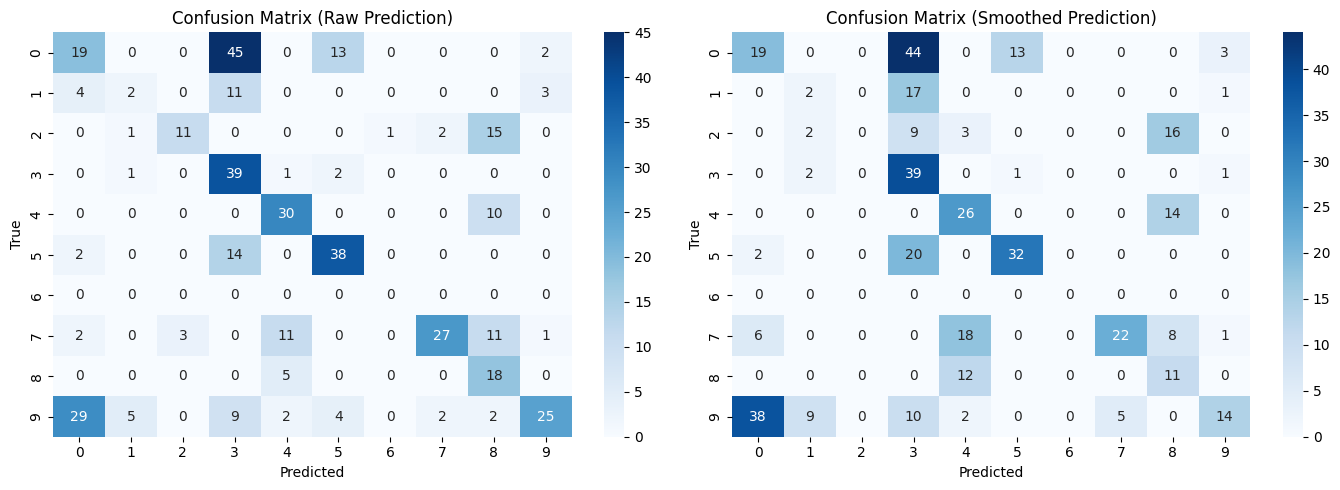

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# --- y_true, y_pred, y_pred_smooth がある前提 ---

num_classes = len(np.unique(y_true))   # 自動でクラス数を取得
class_names = [str(i) for i in range(num_classes)]  # '0','1','2',... に変換

# ---------- Confusion Matrices ----------
cm_raw = confusion_matrix(y_true, y_pred, labels=range(num_classes))
cm_smooth = confusion_matrix(y_true, y_pred_smooth, labels=range(num_classes))

plt.figure(figsize=(14, 5))

# ---------- Raw ----------
plt.subplot(1,2,1)
sns.heatmap(cm_raw, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Raw Prediction)")
plt.xlabel("Predicted")
plt.ylabel("True")

# ---------- Smoothed ----------
plt.subplot(1,2,2)
sns.heatmap(cm_smooth, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (Smoothed Prediction)")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()



Mean duration (true): {np.int64(7): np.float64(11.0), np.int64(9): np.float64(15.6), np.int64(0): np.float64(15.8), np.int64(5): np.float64(10.8), np.int64(3): np.float64(8.6), np.int64(1): np.float64(4.2105263157894735), np.int64(10): np.float64(14.0), np.int64(2): np.float64(6.0), np.int64(8): np.float64(4.6), np.int64(4): np.float64(8.421052631578947)}
Mean duration (raw): {np.int64(7): np.float64(8.857142857142858), np.int64(9): np.float64(7.2727272727272725), np.int64(3): np.float64(13.787234042553191), np.int64(0): np.float64(8.592592592592593), np.int64(5): np.float64(10.857142857142858), np.int64(1): np.float64(6.909090909090909), np.int64(8): np.float64(7.724137931034483), np.int64(4): np.float64(9.636363636363637), np.int64(6): np.float64(4.0), np.int64(2): np.float64(4.0)}
Mean duration (smooth): {np.int64(7): np.float64(15.428571428571429), np.int64(9): np.float64(13.5), np.int64(5): np.float64(15.333333333333334), np.int64(3): np.float64(25.79310344827586), np.int64(1): np

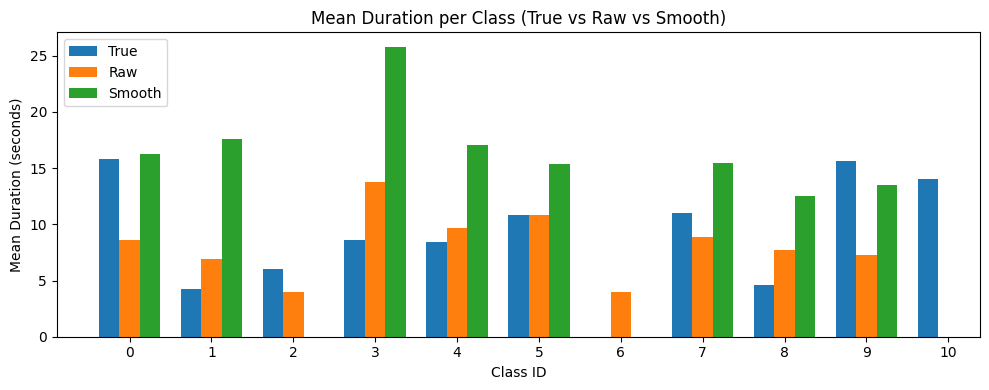

In [44]:
import numpy as np
from collections import defaultdict

def compute_mean_duration(y_seq, seconds_per_window):
    """
    y_seq: 時系列ラベル (list / np.array)
    seconds_per_window: ウィンドウ1個あたりの秒数
    """
    y_seq = np.asarray(y_seq)
    n = len(y_seq)

    durations = defaultdict(list)

    start = 0
    for i in range(1, n):
        if y_seq[i] != y_seq[i-1]:
            # 直前までの連続区間を確定
            cls = y_seq[i-1]
            length = i - start
            durations[cls].append(length * seconds_per_window)
            start = i

    # 最後の区間
    cls = y_seq[-1]
    length = n - start
    durations[cls].append(length * seconds_per_window)

    # 平均継続時間
    mean_durations = {}
    for cls, spans in durations.items():
        mean_durations[cls] = np.mean(spans)

    return mean_durations

seconds_per_window = 4   # 例: 8.533 秒

mean_true = compute_mean_duration(y_true, seconds_per_window)
mean_raw  = compute_mean_duration(y_pred, seconds_per_window)
mean_smooth = compute_mean_duration(y_pred_smooth, seconds_per_window)

print("Mean duration (true):", mean_true)
print("Mean duration (raw):", mean_raw)
print("Mean duration (smooth):", mean_smooth)

import pandas as pd

# クラス一覧（例: 0,1,2）
classes = sorted(set(list(mean_true.keys()) +
                     list(mean_raw.keys()) +
                     list(mean_smooth.keys())))

rows = []
for cls in classes:
    rows.append([
        cls,
        mean_true.get(cls, np.nan),
        mean_raw.get(cls, np.nan),
        mean_smooth.get(cls, np.nan),
    ])

df_duration = pd.DataFrame(
    rows,
    columns=["class", "true_mean_sec", "raw_mean_sec", "smooth_mean_sec"]
)

print(df_duration)

import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(df_duration))
width = 0.25  # 棒の幅

plt.figure(figsize=(10,4))

plt.bar(x - width, df_duration["true_mean_sec"],   width, label="True")
plt.bar(x,         df_duration["raw_mean_sec"],    width, label="Raw")
plt.bar(x + width, df_duration["smooth_mean_sec"], width, label="Smooth")

plt.xticks(x, df_duration["class"])
plt.xlabel("Class ID")
plt.ylabel("Mean Duration (seconds)")
plt.title("Mean Duration per Class (True vs Raw vs Smooth)")
plt.legend()
plt.tight_layout()
plt.show()


In [35]:
import os
import json
import numpy as np


# ==== 平滑化関数：移動多数決 ====
def smooth_majority(y, k=3):
    y = np.asarray(y)
    out = y.copy()

    left = k // 2
    right = k - left - 1
    n = len(y)

    for i in range(n):
        l = max(0, i - left)
        r = min(n, i + right + 1)
        segment = y[l:r]
        out[i] = np.bincount(segment).argmax()

    return out


base_dir = "results_loso"

# === 対象となる T6〜T10 のフォルダ名 ===
target_prefix = ["T6_", "T7_", "T8_", "T9_", "T10_"]

# === seed0〜seed5 を処理 ===
for seed in range(6):
    seed_dir = os.path.join(base_dir, f"seed{seed}")
    if not os.path.exists(seed_dir):
        continue

    print(f"\n=== Processing {seed_dir} ===")

    # --- seed 内のディレクトリ一覧 ---
    for tdir in os.listdir(seed_dir):

        # T6〜T10 のフォルダだけ対象にする
        if not any(tdir.startswith(prefix) for prefix in target_prefix):
            continue

        full_src = os.path.join(seed_dir, tdir)
        if not os.path.isdir(full_src):
            continue

        # smooth フォルダ名
        smooth_dir = tdir + "_smooth"
        full_dst = os.path.join(seed_dir, smooth_dir)
        os.makedirs(full_dst, exist_ok=True)

        print(f"  Variant: {tdir} → {smooth_dir}")

        # JSON 一つずつ平滑化して保存
        for fname in os.listdir(full_src):

            if not fname.endswith(".json"):
                continue

            src_path = os.path.join(full_src, fname)
            dst_path = os.path.join(full_dst, fname)

            # --- 元 JSON 読み込み ---
            with open(src_path, "r") as fp:
                data = json.load(fp)

            y_pred = np.array(data["y_pred"])
            y_pred_smooth = smooth_majority(y_pred, k=5)

            # --- 置換して保存 ---
            data["y_pred"] = y_pred_smooth.tolist()

            with open(dst_path, "w") as fp:
                json.dump(data, fp, indent=2)

            print(f"    Saved {dst_path}")

print("\nDone.")



=== Processing results_loso/seed0 ===
  Variant: T6_noPT_uniform → T6_noPT_uniform_smooth
    Saved results_loso/seed0/T6_noPT_uniform_smooth/U0101.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/U0102.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/U0103.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/U0104.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/U0105.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/U0106.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/U0107.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/U0108.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/U0109.json
    Saved results_loso/seed0/T6_noPT_uniform_smooth/U0110.json
  Variant: T7_noPT_layerwise → T7_noPT_layerwise_smooth
    Saved results_loso/seed0/T7_noPT_layerwise_smooth/U0101.json
    Saved results_loso/seed0/T7_noPT_layerwise_smooth/U0102.json
    Saved results_loso/seed0/T7_noPT_layerwise_smooth/U0103.json
    Saved results_loso/seed0

# LOOCV


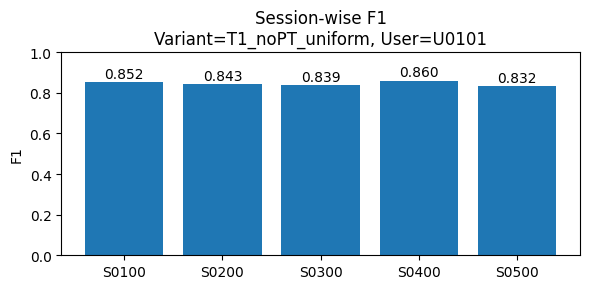

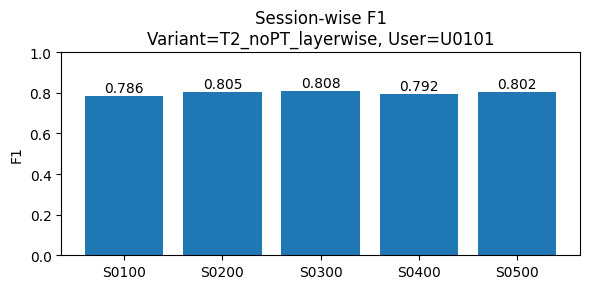

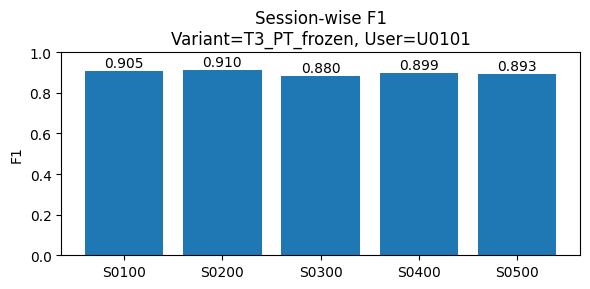

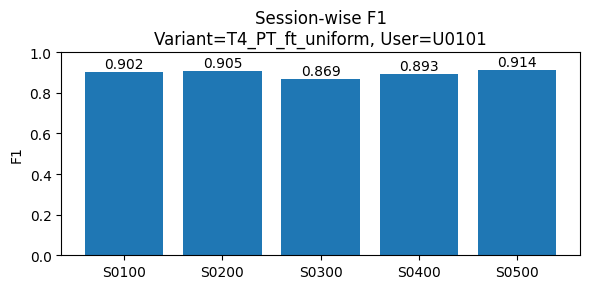

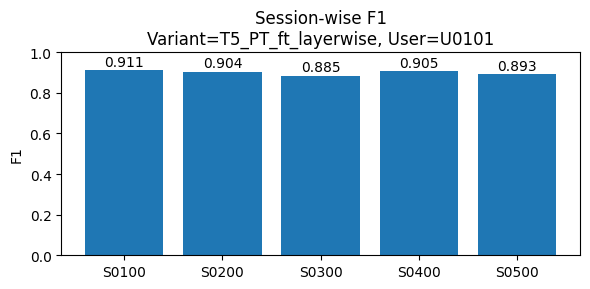

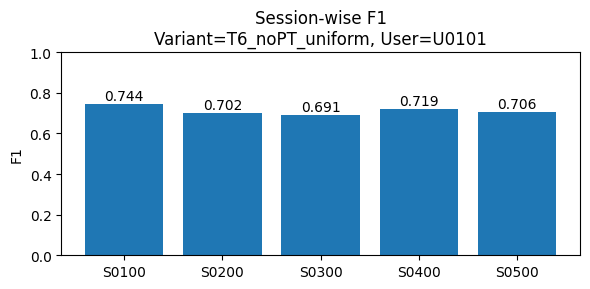

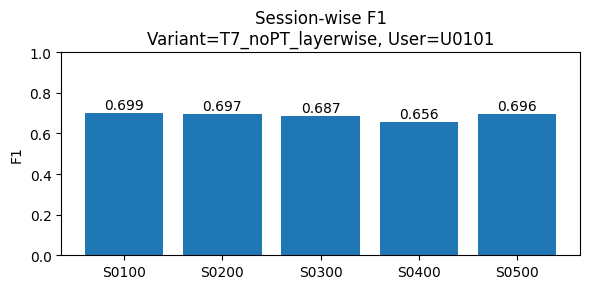

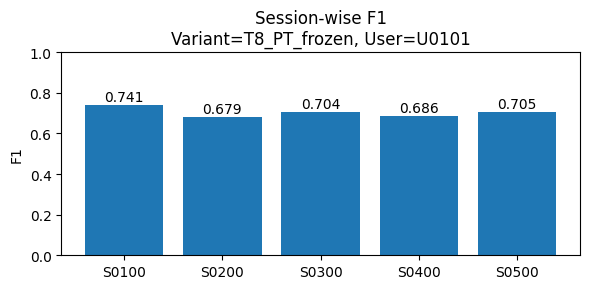

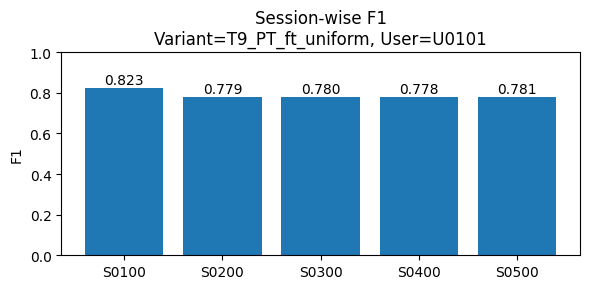

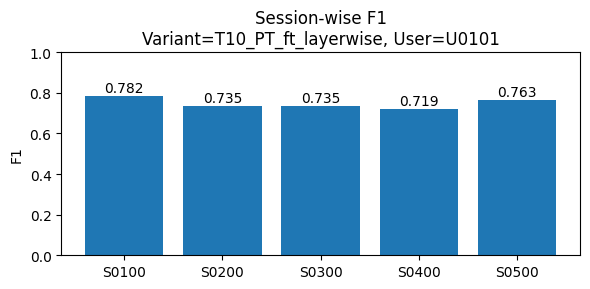

In [8]:
import os
import json
from sklearn.metrics import f1_score

def load_and_compute_f1(base_dir, variant, user, seed=0):
    """
    base_dir: results_loso
    variant : "T1_noPT_uniform"
    user    : "U0101"
    seed    : 0
    """

    target_dir = f"{base_dir}/seed{seed}/{variant}"
    session_f1 = {}

    for sess in sorted(os.listdir(target_dir)):
        sess_dir = os.path.join(target_dir, sess)
        json_path = os.path.join(sess_dir, f"{user}.json")

        if not os.path.isfile(json_path):
            continue

        # --- JSON 読み込み ---
        with open(json_path, "r") as fp:
            data = json.load(fp)

        y_true = data["y_true"]
        y_pred = data["y_pred"]

        # --- F1 計算（weighted） ---
        f1 = f1_score(y_true, y_pred, average="weighted")
        session_f1[sess] = f1

    return session_f1

import matplotlib.pyplot as plt

def plot_f1_bar_for_user(session_f1, variant, user):
    sessions = list(session_f1.keys())
    f1_values = [session_f1[s] for s in sessions]

    plt.figure(figsize=(6, 3))
    plt.bar(sessions, f1_values)

    plt.title(f"Session-wise F1\nVariant={variant}, User={user}")
    plt.ylabel("F1")
    plt.ylim(0, 1)

    for i, v in enumerate(f1_values):
        plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

    plt.tight_layout()
    plt.show()

# T10_PT_ft_layerwise  T3_PT_frozen	 T6_noPT_uniform    T9_PT_ft_uniform
# T1_noPT_uniform      T4_PT_ft_uniform	 T7_noPT_layerwise
# T2_noPT_layerwise    T5_PT_ft_layerwise  T8_PT_frozen
user =  "U0101"
variants = ["T1_noPT_uniform", "T2_noPT_layerwise", "T3_PT_frozen", "T4_PT_ft_uniform",
            "T5_PT_ft_layerwise", "T6_noPT_uniform", "T7_noPT_layerwise", "T8_PT_frozen",
            "T9_PT_ft_uniform", "T10_PT_ft_layerwise"]
for variant in variants:
    session_f1 = load_and_compute_f1(
        base_dir="results_loso",
        variant=variant,
        user=user,
        seed=0
    )
    plot_f1_bar_for_user(session_f1, variant, user)


In [18]:
def compute_user_score(base_dir, variant, user, seed=0):
    """
    variant / session / user.json からF1を読んで
    session平均 = ユーザスコア として返す。
    """
    import os, json
    from sklearn.metrics import f1_score
    import numpy as np

    target_dir = f"{base_dir}/seed{seed}/{variant}"
    f1_list = []

    for sess in sorted(os.listdir(target_dir)):
        json_path = os.path.join(target_dir, sess, f"{user}.json")
        if not os.path.isfile(json_path):
            continue

        with open(json_path, "r") as fp:
            data = json.load(fp)

        f1 = f1_score(data["y_true"], data["y_pred"], average="weighted")
        f1_list.append(f1)

    if len(f1_list) == 0:
        return None

    return float(np.mean(f1_list))

def compute_variant_stats(base_dir, variant, users, seed=0):
    """
    1つの variant について、
    全ユーザの UserScore を集計して mean, std を返す。
    """

    import numpy as np

    scores = []
    for user in users:
        f1 = compute_user_score(base_dir, variant, user, seed)
        if f1 is not None:
            scores.append(f1)

    scores = np.array(scores)

    return {
        "variant": variant,
        "mean_f1": float(scores.mean()),
        "std_f1": float(scores.std()),
        "num_users": len(scores),
        "scores": scores,
    }

import pandas as pd

def collect_all_variants(base_dir, variants, users, seed=0):
    rows = []
    for v in variants:
        stats = compute_variant_stats(base_dir, v, users, seed)
        rows.append([
            v,
            stats["mean_f1"],
            stats["std_f1"],
        ])
    df = pd.DataFrame(rows, columns=["variant", "mean_f1", "std_f1"])
    return df


import matplotlib.pyplot as plt
import numpy as np


# --- 色：5種類（あなたの設定） ---
colors5 = [
    "#4e79a7",  # 1: Random Init + Uniform
    "#f28e2c",  # 2: Random Init + Layerwise
    "#e15759",  # 3: Pretrain + Frozen
    "#76b7b2",  # 4: Pretrain + FT-Uniform
    "#59a14f",  # 5: Pretrain + FT-Layerwise
]

labels5 = [
    "Random Init + Uniform",
    "Random Init + Layerwise",
    "Pretrain + Frozen",
    "Pretrain + Finetune-Uniform",
    "Pretrain + Finetune-Layerwise",
]

# --- あなたのグループ分け ---
group_A = ["T6_noPT_uniform","T7_noPT_layerwise","T8_PT_frozen","T9_PT_ft_uniform","T10_PT_ft_layerwise"]
group_C = ["T1_noPT_uniform","T2_noPT_layerwise","T3_PT_frozen","T4_PT_ft_uniform","T5_PT_ft_layerwise"]
# B群（smooth系）は今回は無しなので省略可

def label_group(v):
    if v in group_A:
        return "A"
    elif v in group_C:
        return "C"
    else:
        return "Unknown"


def plot_variant_bar_with_groups(df):
    # --- グループ名追加 ---
    df["group"] = df["variant"].apply(label_group)

    # --- A → C の順で並べる ---
    df_sorted = pd.concat([
        df[df["group"]=="A"],
        df[df["group"]=="C"],
    ], axis=0).reset_index(drop=True)

    variants = df_sorted["variant"].tolist()
    means    = df_sorted["mean_f1"].to_numpy()
    stds     = df_sorted["std_f1"].to_numpy()
    groups   = df_sorted["group"].tolist()

    # --- X軸位置（グループ間に大きめの空白） ---
    x = []
    gap = 2.0
    pos = 0

    for i, g in enumerate(groups):
        if i > 0 and groups[i-1] != g:
            pos += gap  # グループ間の隙間
        x.append(pos)
        pos += 0.9

    x = np.array(x)

    # --- グループ内（5パターン）で色を割り当て ---
    idx_group = [(i % 5) for i in range(len(variants))]
    bar_colors = [colors5[idx] for idx in idx_group]

    # --- Plot ---
    plt.figure(figsize=(14, 6))

    plt.bar(
        x, means, yerr=stds,
        color=bar_colors,
        capsize=6,
        edgecolor="black",
        linewidth=1.2
    )

    # --- 数値をバーに書く ---
    for xi, m, s in zip(x, means, stds):
        plt.text(xi, m + 0.015, f"{m:.3f}",
                 ha="center", fontsize=11, fontweight="bold")
        plt.text(xi, m - 0.05, f"±{s:.3f}",
                 ha="center", fontsize=10)

    plt.xticks([], [])
    plt.ylabel("User-level Weighted F1", fontsize=12)
    plt.ylim(0, 1.05)

    # --- グループ中央位置 ---
    idx_A = np.where(df_sorted["group"]=="A")[0]
    idx_C = np.where(df_sorted["group"]=="C")[0]
    mid_A = np.mean(x[idx_A])
    mid_C = np.mean(x[idx_C])

    plt.text(mid_A, -0.12, "CNN-Linear", ha="center", fontsize=13)
    plt.text(mid_C, -0.12, "MultiCNN-Transformer", ha="center", fontsize=13)

    # --- 凡例 ---
    handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors5]
    plt.legend(handles, labels5, ncol=3, fontsize=11, loc="upper center")

    plt.title("User-level F1 (session-averaged) per Variant", fontsize=15)
    plt.tight_layout()
    plt.show()




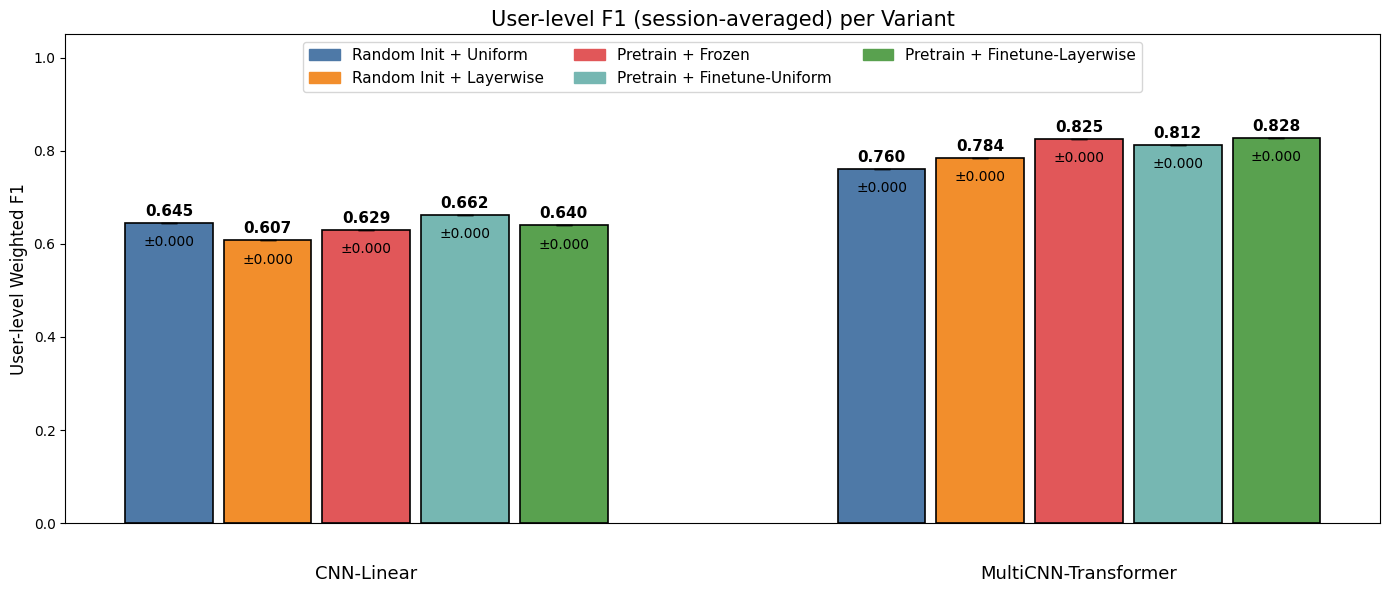

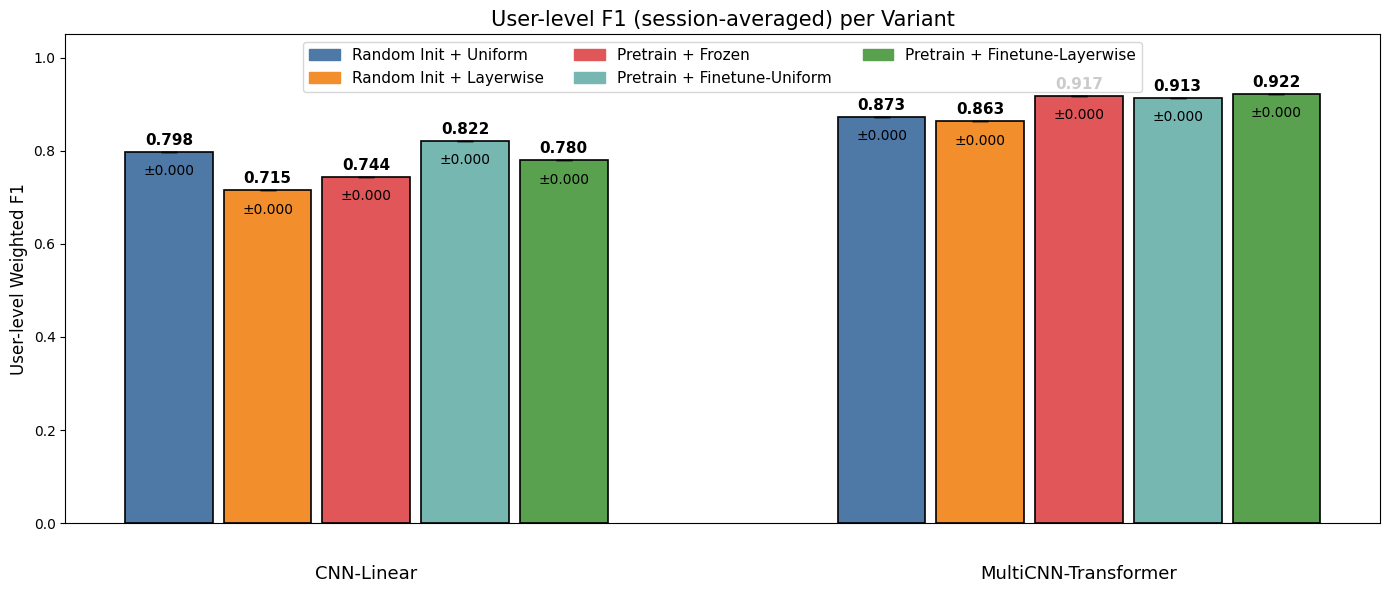

In [23]:
users = ["U0104"]

variants = [
    "T1_noPT_uniform","T2_noPT_layerwise","T3_PT_frozen",
    "T4_PT_ft_uniform","T5_PT_ft_layerwise",
    "T6_noPT_uniform","T7_noPT_layerwise","T8_PT_frozen",
    "T9_PT_ft_uniform","T10_PT_ft_layerwise"
]

# 集計
df = collect_all_variants("results_loso", variants, users, seed=0)

# 描画
plot_variant_bar_with_groups(df)

users = ["U0103"]

variants = [
    "T1_noPT_uniform","T2_noPT_layerwise","T3_PT_frozen",
    "T4_PT_ft_uniform","T5_PT_ft_layerwise",
    "T6_noPT_uniform","T7_noPT_layerwise","T8_PT_frozen",
    "T9_PT_ft_uniform","T10_PT_ft_layerwise"
]

# 集計
df = collect_all_variants("results_loso", variants, users, seed=0)

# 描画
plot_variant_bar_with_groups(df)

    


In [7]:
!ls results_loso/seed0

T10_PT_ft_layerwise  T3_PT_frozen	 T6_noPT_uniform    T9_PT_ft_uniform
T1_noPT_uniform      T4_PT_ft_uniform	 T7_noPT_layerwise
T2_noPT_layerwise    T5_PT_ft_layerwise  T8_PT_frozen


In [1]:
import os
import json
import numpy as np


# ==== 平滑化関数：移動多数決 ====
def smooth_majority(y, k=9):
    y = np.asarray(y)
    out = y.copy()

    left = k // 2
    right = k - left - 1
    n = len(y)

    for i in range(n):
        l = max(0, i - left)
        r = min(n, i + right + 1)
        segment = y[l:r]
        out[i] = np.bincount(segment).argmax()

    return out


base_dir = "results_loso_limited"

# === 対象となる T6〜T10 のフォルダ名 ===
target_prefix = ["T6_", "T7_", "T8_", "T9_", "T10_"]

# === seed0〜seed5 を処理 ===
for seed in range(6):
    seed_dir = os.path.join(base_dir, f"seed{seed}")
    if not os.path.exists(seed_dir):
        print(f"\n=== Skipping {seed_dir} (not found) ===")
        continue

    print(f"\n=== Processing {seed_dir} ===")

    # --- seed 内の variant を走査 ---
    for tdir in os.listdir(seed_dir):

        # T6〜T10 のフォルダのみ対象
        if not any(tdir.startswith(prefix) for prefix in target_prefix):
            continue

        full_src = os.path.join(seed_dir, tdir)
        if not os.path.isdir(full_src):
            continue

        # === smooth 用ディレクトリを作成 ===
        smooth_dir = tdir + "_smooth"
        full_dst = os.path.join(seed_dir, smooth_dir)
        os.makedirs(full_dst, exist_ok=True)

        print(f"  Variant: {tdir} → {smooth_dir}")

        # === 各 session ディレクトリを処理 ===
        for sess in os.listdir(full_src):
            sess_src = os.path.join(full_src, sess)
            if not os.path.isdir(sess_src):
                continue

            sess_dst = os.path.join(full_dst, sess)
            os.makedirs(sess_dst, exist_ok=True)

            # === 各 JSON ===
            for fname in os.listdir(sess_src):
                if not fname.endswith(".json"):
                    continue

                src_path = os.path.join(sess_src, fname)
                dst_path = os.path.join(sess_dst, fname)

                # --- JSON 読み込み ---
                with open(src_path, "r") as fp:
                    data = json.load(fp)

                y_pred = np.array(data["y_pred"])
                y_pred_smooth = smooth_majority(y_pred, k=5)

                # --- 保存 ---
                data["y_pred"] = y_pred_smooth.tolist()

                with open(dst_path, "w") as fp:
                    json.dump(data, fp, indent=2)

                print(f"    Saved {dst_path}")

print("\nDone.")



=== Processing results_loso_limited/seed0 ===
  Variant: T6_noPT_uniform → T6_noPT_uniform_smooth
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0100/U0101.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0100/U0102.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0100/U0103.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0100/U0104.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0100/U0105.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0100/U0106.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0100/U0107.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0100/U0108.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0100/U0109.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0100/U0110.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_smooth/S0200/U0101.json
    Saved results_loso_limited/seed0/T6_noPT_uniform_s

In [24]:
import os
import json
import numpy as np
from sklearn.metrics import f1_score
import re
import matplotlib.pyplot as plt

def load_openpack_subject_f1(
    root,               # e.g., "results_loso/1212_3"
    target_seed="seed0",
    target_session="S0100",
):
    """
    return:
      {
        variant: {
          "U0101": {"macro": f1, "weighted": f1},
          "U0102": {...},
          ...
        }
      }
    """
    out = {}
    seed_dir = os.path.join(root, target_seed)
    if not os.path.isdir(seed_dir):
        raise ValueError(f"seed not found: {seed_dir}")

    for variant in sorted(os.listdir(seed_dir)):
        var_dir = os.path.join(seed_dir, variant)
        if not os.path.isdir(var_dir):
            continue

        sess_dir = os.path.join(var_dir, target_session)
        if not os.path.isdir(sess_dir):
            continue

        out[variant] = {}
        for fname in sorted(os.listdir(sess_dir)):
            if not fname.endswith(".json"):
                continue

            # U0101.json → "U0101"
            user = fname.replace(".json", "")
            # 念のため数字が無いものはスキップ
            if re.search(r"\d+", user) is None:
                continue

            with open(os.path.join(sess_dir, fname)) as fp:
                r = json.load(fp)

            y = np.array(r["y_true"])
            p = np.array(r["y_pred"])

            out[variant][user] = {
                "macro":    f1_score(y, p, average="macro"),
                "weighted": f1_score(y, p, average="weighted"),
            }
    return out

def extract_common_subjects(model_f1):
    subjects = None
    for d in model_f1.values():
        s = set(d.keys())
        subjects = s if subjects is None else subjects & s
    return sorted(subjects)

def plot_macro_weighted(
    model_f1,
    model_names=None,   # Noneなら全variant
    name_dict=None,
):
    if model_names is None:
        model_names = sorted(model_f1.keys())

    subject_ids = extract_common_subjects({k: model_f1[k] for k in model_names})

    # x 軸（U0101 などそのまま）
    x_labels = subject_ids + ["Overall"]

    colors = [
        "#E1812C", "#9467bd", "#556b2f",
        "#75c9eb", "#d62728", "#8c564b"
    ]
    spacing = 1.2
    x = np.arange(len(x_labels)) * spacing
    width = max(0.1, 0.8 / len(model_names))

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), dpi=200, sharex=True)

    for ax, metric, title in zip(
        axes, ["macro", "weighted"], ["Macro F1", "Weighted F1"]
    ):
        for i, model in enumerate(model_names):
            f1_dict = model_f1[model]
            scores = [f1_dict[sid][metric] for sid in subject_ids]
            scores.append(np.mean(scores))  # Overall（被験者平均）
            label_name = name_dict.get(model, model) if name_dict else model

            offset = (i - (len(model_names)-1)/2) * width
            ax.bar(
                x + offset, scores, width=width,
                color=colors[i % len(colors)],
                edgecolor="black", alpha=0.9,
                label=label_name if metric == "macro" else None
            )

        # grid
        for y in np.arange(0, 1.01, 0.2):
            ax.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)
        for y in np.arange(0, 1.01, 0.05):
            ax.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

        ax.set_ylim(0, 1.05)
        ax.set_ylabel(title)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(x_labels, fontsize=9)
    axes[-1].set_xlabel("Subject")

    axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.35),
                   ncol=5, frameon=False)

    plt.tight_layout()
    plt.show()



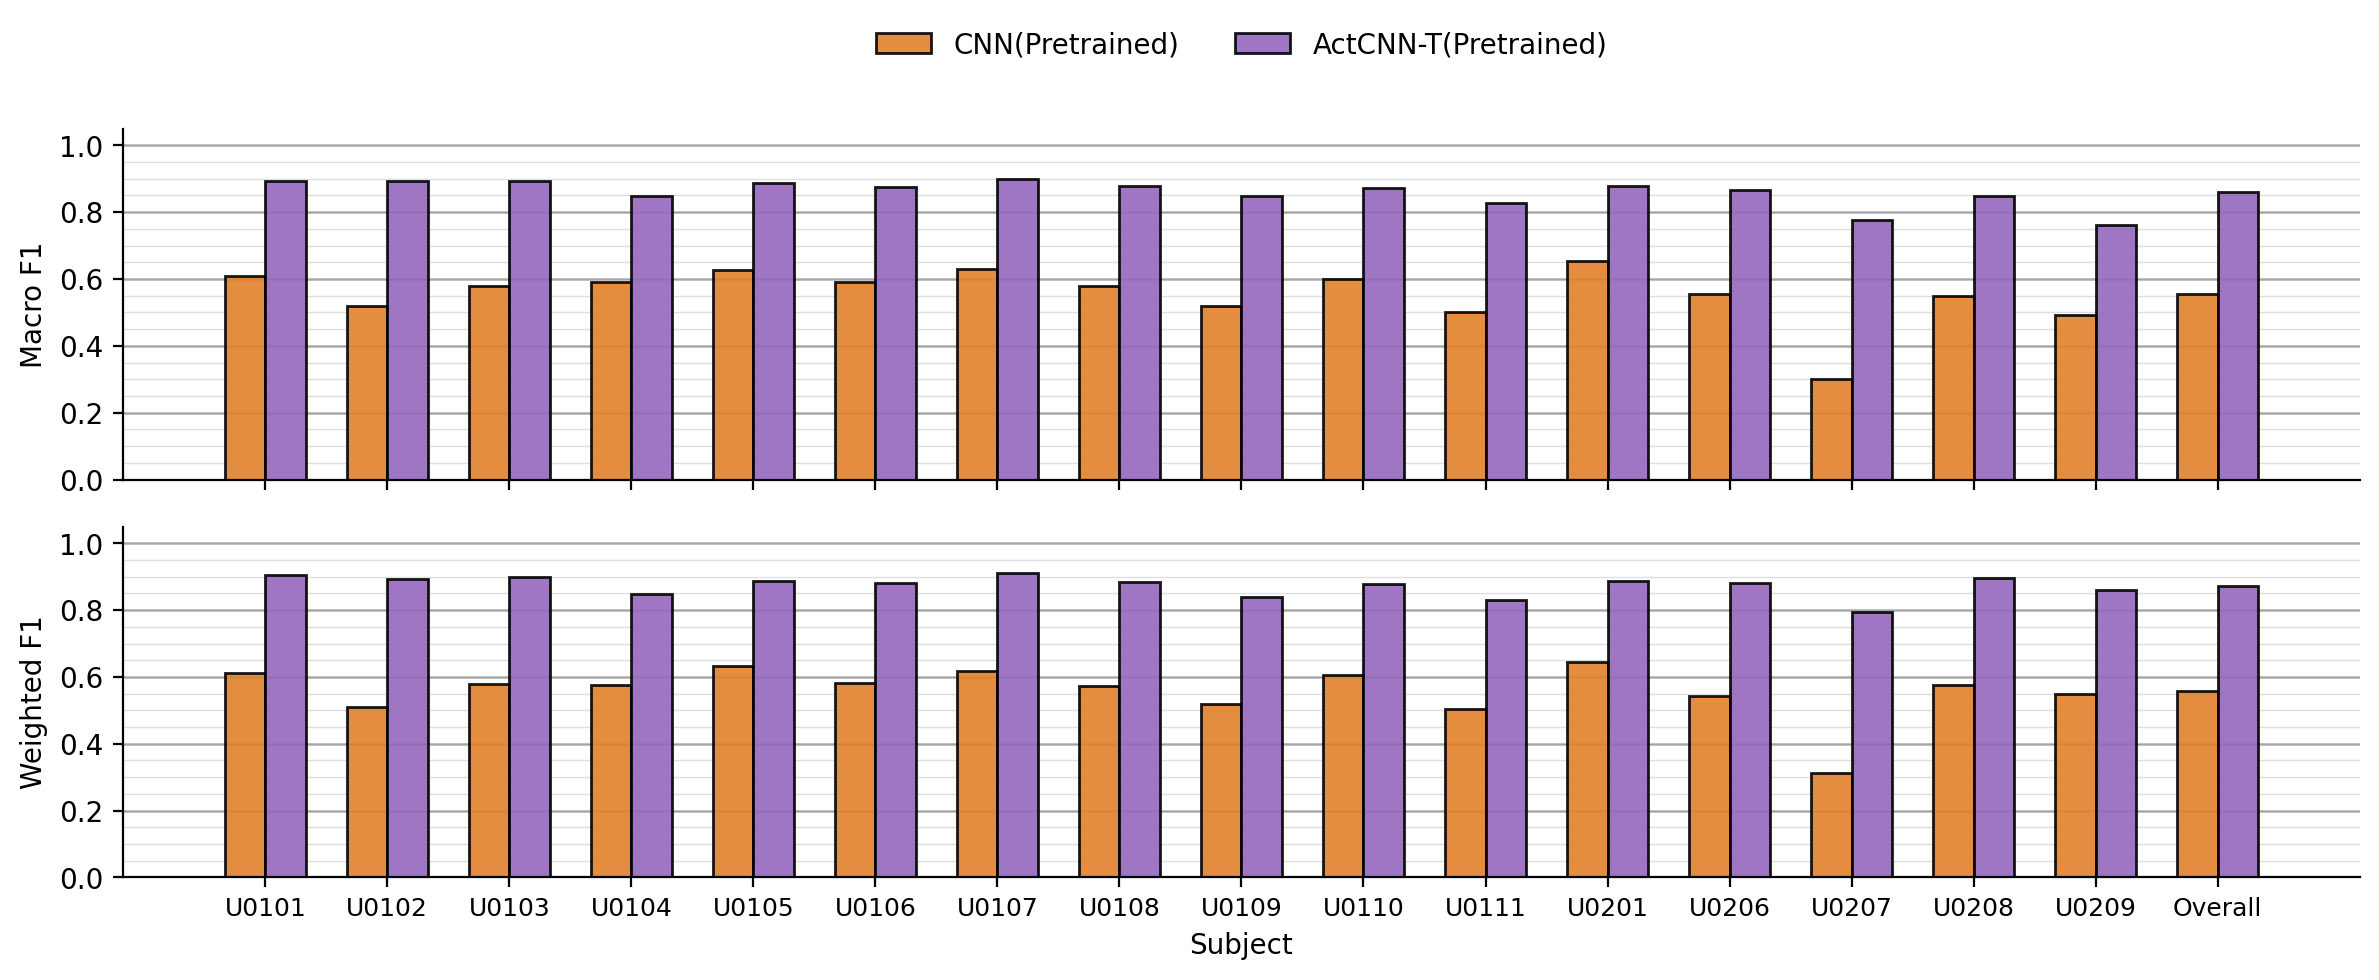

In [ ]:
root = "results_loso/1214_3"
#root = "results_loso/1215_2"

model_f1 = load_openpack_subject_f1(
    root=root,
    target_seed="seed0",
    target_session="S0100",
)

# model_names = [
#     "T1_noPT_uniform",
#     "T3_PT_frozen",
#     #"T4_PT_ft_uniform",
#     #"T5_PT_ft_layerwise",
#     "T11_noPT_uniform",
#     "T12_noPT_uniform",
# ]

# model_names = [
#     "T1_cnn",
#     "T3_precnn",
#     "T4_PT_ft_uniform",
#     "T5_PT_ft_layerwise",
#     "T2_dct",
#     "T3_cnn-transformer",
#     "T5_precnn-transformer",
# ]

model_names = [
    #"T1_cnn",
    "T2_precnn",
    #"T3_dct",
    #"T4_cnn-transformer",
    "T5_precnn-transformer",
]

name_dict = {
    "T1_cnn": "CNN",
    "T2_precnn": "CNN(Pretrained)",
    "T3_dct": "DCT",
    "T4_cnn-transformer": "ActCNN_T",
    "T5_precnn-transformer": "ActCNN-T(Pretrained)",
}

plot_macro_weighted(model_f1, model_names=model_names, name_dict=name_dict)


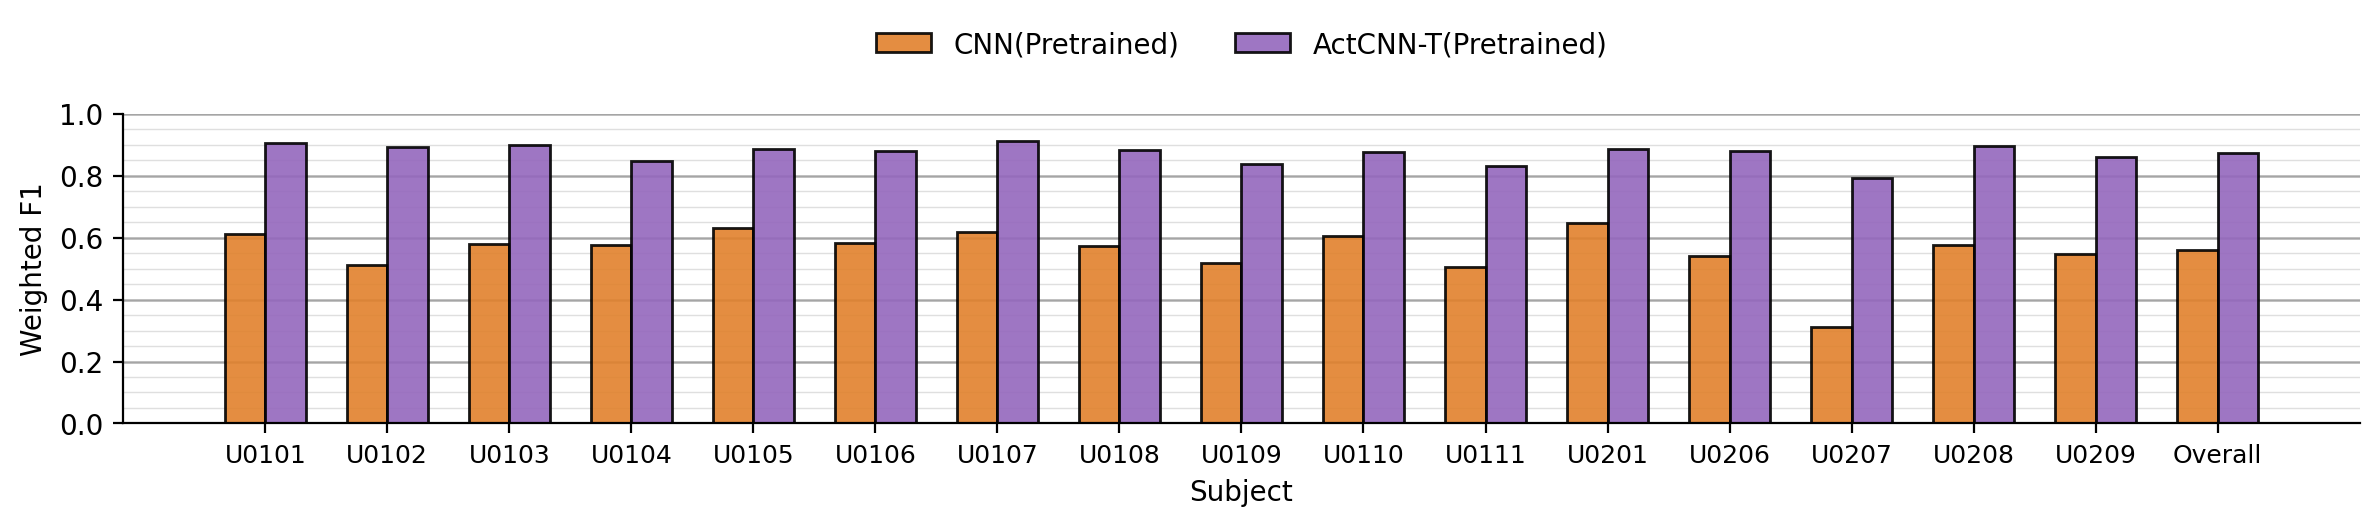

In [47]:
def plot_weighted_f1(
    model_f1,
    model_names=None,
    name_dict=None,
):
    if model_names is None:
        model_names = sorted(model_f1.keys())

    subject_ids = extract_common_subjects({k: model_f1[k] for k in model_names})

    # x 軸
    x_labels = subject_ids + ["Overall"]

    colors = [
        "#E1812C", "#9467bd", "#556b2f",
        "#75c9eb", "#d62728", "#8c564b"
    ]
    spacing = 1.2
    x = np.arange(len(x_labels)) * spacing
    width = max(0.1, 0.8 / len(model_names))

    fig, ax = plt.subplots(1, 1, figsize=(12, 3), dpi=200)

    for i, model in enumerate(model_names):
        f1_dict = model_f1[model]
        scores = [f1_dict[sid]["weighted"] for sid in subject_ids]
        scores.append(np.mean(scores))  # Overall

        label_name = name_dict.get(model, model) if name_dict else model
        offset = (i - (len(model_names)-1)/2) * width

        ax.bar(
            x + offset, scores, width=width,
            color=colors[i % len(colors)],
            edgecolor="black", alpha=0.9,
            label=label_name
        )

    # grid
    for y in np.arange(0, 1.01, 0.2):
        ax.axhline(y, color="gray", lw=0.9, alpha=0.6, zorder=0)
    for y in np.arange(0, 1.01, 0.05):
        ax.axhline(y, color="gray", lw=0.5, alpha=0.25, zorder=0)

    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Weighted F1")
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_xlabel("Subject")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.35),
        ncol=len(model_names),
        frameon=False
    )

    plt.tight_layout()
    plt.show()

plot_weighted_f1(model_f1, model_names=model_names, name_dict=name_dict)

In [48]:
# print overall score
print("--Overall Macro F1--")
for model in model_names:
    f1_dict = model_f1[model]
    scores = [f1_dict[sid]["macro"] for sid in extract_common_subjects({k: model_f1[k] for k in model_names})]
    overall = np.mean(scores)
    print(f"{model}: F1 = {overall:.4f}")

print("")

print("--Overall Weighted F1--")
for model in model_names:
    f1_dict = model_f1[model]
    scores = [f1_dict[sid]["weighted"] for sid in extract_common_subjects({k: model_f1[k] for k in model_names})]
    overall = np.mean(scores)
    print(f"{model}: F1 = {overall:.4f}")

--Overall Macro F1--
T2_precnn: F1 = 0.5563
T5_precnn-transformer: F1 = 0.8589

--Overall Weighted F1--
T2_precnn: F1 = 0.5588
T5_precnn-transformer: F1 = 0.8732


In [49]:
import os
import json
import numpy as np
import re
from sklearn.metrics import confusion_matrix

def load_confusion_all_subjects(
    root,               # e.g. "results_loso/1212_3"
    variant,            # e.g. "T1_noPT_uniform"
    target_seed="seed0",
    target_session="S0100",
    labels=None,
):
    """
    OpenPack 用
    指定 seed / variant / session における
    全被験者の y_true / y_pred を結合して混同行列を作る

    return:
        conf_mat (ndarray): shape = (C, C)
    """

    sess_dir = os.path.join(root, target_seed, variant, target_session)
    if not os.path.isdir(sess_dir):
        raise ValueError(f"session dir not found: {sess_dir}")

    y_true_all = []
    y_pred_all = []

    for fname in sorted(os.listdir(sess_dir)):
        if not fname.endswith(".json"):
            continue

        # U0101.json などのみ対象
        user = fname.replace(".json", "")
        if re.search(r"\d+", user) is None:
            continue

        with open(os.path.join(sess_dir, fname)) as fp:
            r = json.load(fp)

        y_true_all.extend(r["y_true"])
        y_pred_all.extend(r["y_pred"])

    if len(y_true_all) == 0:
        raise ValueError(f"No valid subject JSONs in {sess_dir}")

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)

    cm = confusion_matrix(
        y_true_all,
        y_pred_all,
        labels=labels
    )

    return cm


In [50]:
root = "results_loso/1212_4/seed0"

model_names = [
    "T1_cnn",
    #"T3_precnn",
    #"T4_PT_ft_uniform",
    #"T5_PT_ft_layerwise",
    "T2_dct",
    "T3_cnn-transformer",
    "T4_precnn-transformer",
]

labels = np.arange(10)  # 0〜10 のラベル
conf_mats = {}

for variant in model_names:
    conf_mats[variant] = load_confusion_all_subjects(
        root="results_loso/1212_3",
        variant=variant,
        target_seed="seed0",
        target_session="S0100",
        labels=labels
    )


ValueError: session dir not found: results_loso/1212_3/seed0/T1_cnn/S0100

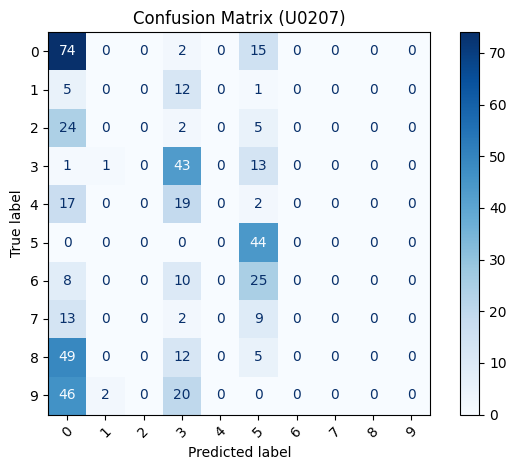

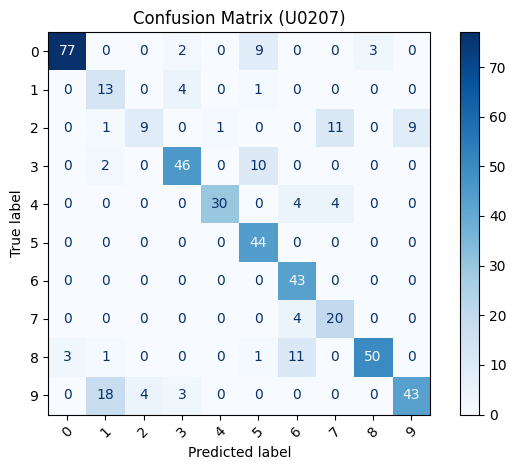

In [ ]:
import json
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


json_path_1 = "results_loso/1214_3/seed0/T4_cnn-transformer/S0100/U0207.json"
json_path_2 = "results_loso/1214_3/seed0/T5_precnn-transformer/S0100/U0207.json"

def plot_cm(json_path):
    with open(json_path) as f:
        r = json.load(f)

    y_true = np.array(r["y_true"])
    y_pred = np.array(r["y_pred"])

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(cm)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion Matrix (U0207)")
    plt.tight_layout()
    plt.show()

plot_cm(json_path_1)
plot_cm(json_path_2)



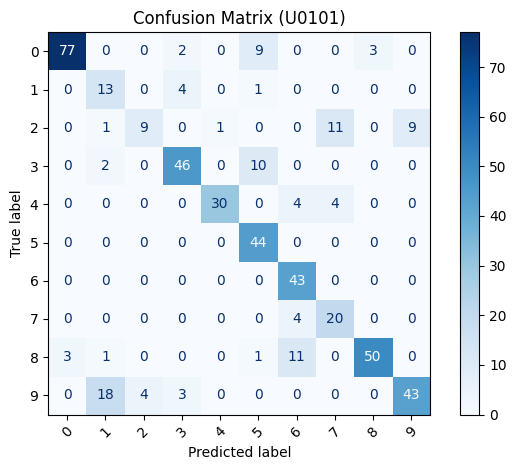

In [ ]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix (U0207)")
plt.tight_layout()
plt.show()


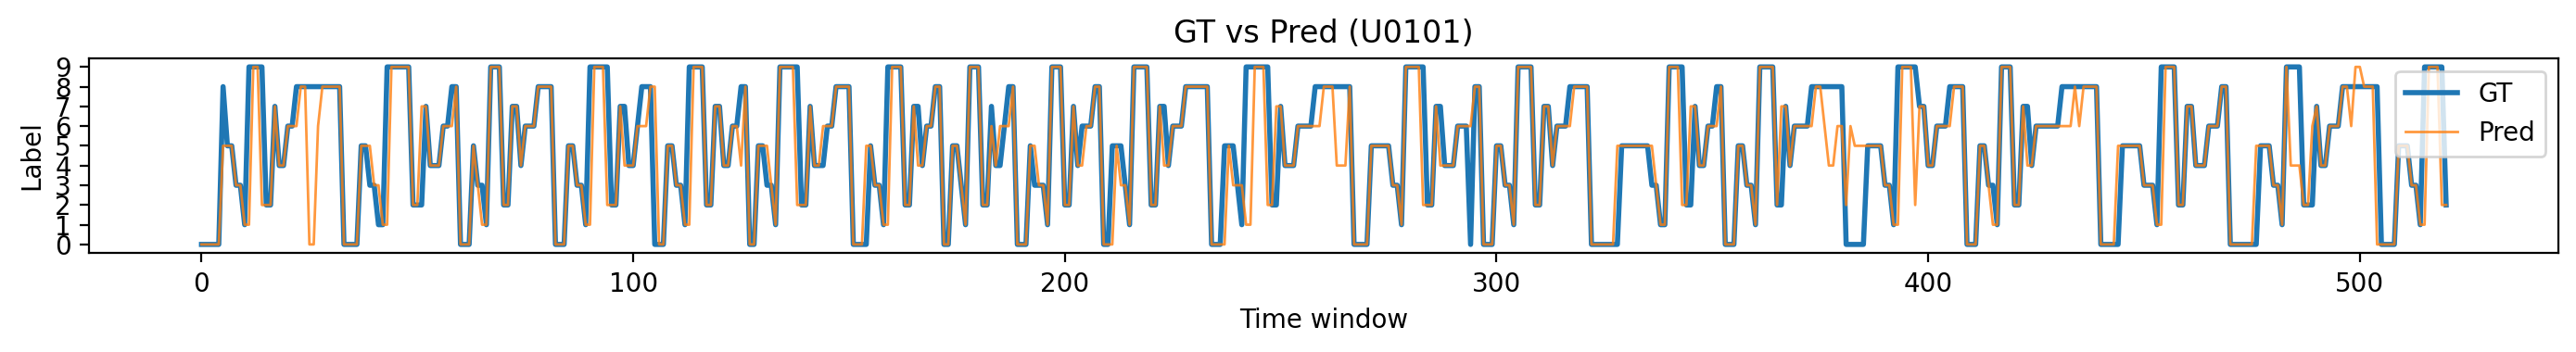

In [ ]:
plt.figure(figsize=(14, 2), dpi=200)

plt.plot(y_true, label="GT", linewidth=2)
plt.plot(y_pred, label="Pred", linewidth=1, alpha=0.8)

plt.yticks(sorted(set(y_true)))
plt.xlabel("Time window")
plt.ylabel("Label")
plt.title("GT vs Pred (U0101)")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
def load_subject_f1_by_session(root, model, session="S0100"):
    out = {}
    sess_dir = os.path.join(root, model, session)

    for fname in sorted(os.listdir(sess_dir)):
        if not fname.endswith(".json"):
            continue
        user = fname.replace(".json", "")
        if re.search(r"\d+", user) is None:
            continue

        with open(os.path.join(sess_dir, fname)) as fp:
            r = json.load(fp)

        y = np.array(r["y_true"])
        p = np.array(r["y_pred"])

        out[user] = {
            "macro": f1_score(y, p, average="macro"),
            "weighted": f1_score(y, p, average="weighted"),
        }
    return out


In [ ]:
import os
import re
import json
import numpy as np
from sklearn.metrics import confusion_matrix

def load_openpack_confusion_matrix(
    root,               # e.g. "results_loso/1212_3"
    variant,            # e.g. "T1_noPT_uniform"
    target_seed="seed0",
    target_session="S0100",
    labels=None,
):
    """
    return:
        conf_mat (ndarray): shape = (C, C)
    """

    sess_dir = os.path.join(root, target_seed, variant, target_session)
    if not os.path.isdir(sess_dir):
        raise ValueError(f"session dir not found: {sess_dir}")

    y_true_all = []
    y_pred_all = []

    for fname in sorted(os.listdir(sess_dir)):
        if not fname.endswith(".json"):
            continue

        # U0101.json などのみ対象
        user = fname.replace(".json", "")
        if re.search(r"\d+", user) is None:
            continue

        with open(os.path.join(sess_dir, fname)) as fp:
            r = json.load(fp)

        y_true_all.extend(r["y_true"])
        y_pred_all.extend(r["y_pred"])

    if len(y_true_all) == 0:
        raise ValueError(f"No valid subject JSONs in {sess_dir}")

    return confusion_matrix(
        np.array(y_true_all),
        np.array(y_pred_all),
        labels=labels
    )


In [ ]:
labels = np.arange(10)  # Inspect / Sort / Transport

model_names = [
    #"T1_cnn",
    "T2_precnn",
    #"T3_dct",
    #"T4_cnn-transformer",
    "T5_precnn-transformer",
]

name_dict = {
    "T1_cnn": "CNN",
    "T2_precnn": "CNN(Pretrained)",
    "T3_dct": "DCT",
    "T4_cnn-transformer": "ActCNN_T",
    "T5_precnn-transformer": "ActCNN-T(Pretrained)",
}

conf_mats = {}


for variant in model_names:   # 例: ["CNN", "CNN(Pretrained)", ...]
    print(f"[INFO] loading CM for {variant}")

    cm = load_openpack_confusion_matrix(
        #root="results_loso/1214_3",
        root="results_loso/1215",
        variant=variant,
        target_seed="seed0",
        target_session="S0100",
        labels=labels,  # Inspect / Sort / Transport
    )

    conf_mats[variant] = cm




[INFO] loading CM for T2_precnn
[INFO] loading CM for T5_precnn-transformer


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_label_timeline(
    samples,
    t_idx,
    y_softmax,
    num_classes=11,
    fps=30,
    title_prefix=""
):
    """
    GT / Pred を色付きラベル帯で可視化
    """
    # --- slice ---
    gt = t_idx[slice(*samples)].ravel()
    pred = y_softmax[slice(*samples)].argmax(axis=-1).ravel()
    T = len(gt)

    # --- color map ---
    cmap = plt.get_cmap("tab10", num_classes)

    fig, ax = plt.subplots(figsize=(20, 2.8), dpi=200)

    # --- GT ---
    for c in range(num_classes):
        mask = gt == c
        ax.barh(
            y=1.0,
            width=mask.astype(int),
            left=np.arange(T),
            height=0.35,
            color=cmap(c),
            edgecolor="none"
        )

    # --- Pred ---
    for c in range(num_classes):
        mask = pred == c
        ax.barh(
            y=0.5,
            width=mask.astype(int),
            left=np.arange(T),
            height=0.35,
            color=cmap(c),
            edgecolor="none"
        )

    # --- style ---
    ax.set_yticks([0.5, 1.0])
    ax.set_yticklabels(["Prediction", "Ground Truth"], fontsize=12)
    ax.set_xlim(0, T)

    xticks = np.arange(0, T, fps * 30)
    ax.set_xticks(xticks)
    ax.set_xticklabels((xticks / fps).astype(int))

    ax.set_xlabel("Time [s]", fontsize=12)
    ax.set_title(
        f"{title_prefix} | {samples[0]}–{samples[1]} min",
        fontsize=14
    )

    # remove clutter
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    fig.tight_layout()
    return fig



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_label_timeline_minute(
    y_true,
    y_pred,
    start_min,
    end_min,
    num_classes=11,
    stride_sec=2,
    title=""
):
    """
    y_true, y_pred (2s stride) を
    分単位で指定して GT / Pred ラベル帯を描画
    """

    # ---- index range ----
    step_per_min = int(60 / stride_sec)   # = 30
    s = start_min * step_per_min
    e = end_min   * step_per_min

    gt = y_true[s:e]
    pred = y_pred[s:e]
    T = len(gt)

    # ---- colormap ----
    cmap = plt.get_cmap("tab10", num_classes)

    fig, ax = plt.subplots(figsize=(20, 2.8), dpi=200)

    # ---- Ground Truth ----
    for c in range(num_classes):
        mask = gt == c
        ax.barh(
            y=1.0,
            width=mask.astype(int),
            left=np.arange(T),
            height=0.35,
            color=cmap(c),
            edgecolor="none",
            alpha=0.8
        )

    # ---- Prediction ----
    for c in range(num_classes):
        mask = pred == c
        # ax.barh(
        #     y=0.5,
        #     width=mask.astype(int),
        #     left=np.arange(T),
        #     height=0.35,
        #     color=cmap(c),
        #     edgecolor="none"
        # )
        # Prediction 側だけ
        ax.barh(
            y=0.5,
            width=mask.astype(int),
            left=np.arange(T),
            height=0.32,
            color=cmap(c),
            edgecolor="none",
            alpha=0.8   # ← ここ
        )


    # ---- style ----
    ax.set_yticks([0.5, 1.0])
    ax.set_yticklabels(["Prediction", "Ground Truth"], fontsize=15)
    ax.set_xlim(0, T)

    # x-axis (minute)
    xticks = np.arange(0, T + 1, step_per_min)
    ax.set_xticks(xticks)
    ax.set_xticklabels(start_min + xticks // step_per_min, fontsize=15)

    ax.set_xlabel("Time [min]", fontsize=15)
    # ax.set_title(
    #     f"{title} | {start_min}–{end_min} min",
    #     fontsize=14
    # )

    # clean look
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()
    return fig


In [ ]:
import json
import numpy as np

def load_labels_from_json(json_path):
    """
    JSON から y_true, y_pred を読み込む
    どちらも shape (T,) を想定
    """
    with open(json_path, "r") as f:
        r = json.load(f)

    y_true = np.asarray(r["y_true"], dtype=int)
    y_pred = np.asarray(r["y_pred"], dtype=int)

    assert len(y_true) == len(y_pred), "y_true and y_pred length mismatch"

    return y_true, y_pred


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_label_timeline_minute(
    y_true,
    y_pred,
    start_min,
    end_min,
    num_classes=11,
    stride_sec=2,
    title=""
):
    """
    y_true, y_pred (2s stride) を
    分単位で指定して GT / Pred ラベル帯を描画
    """

    # ---- index range ----
    step_per_min = int(60 / stride_sec)   # = 30
    s = start_min * step_per_min
    e = end_min   * step_per_min

    gt = y_true[s:e]
    pred = y_pred[s:e]
    T = len(gt)

    # ---- colormap ----
    cmap = plt.get_cmap("tab10", num_classes)

    fig, ax = plt.subplots(figsize=(20, 2.8), dpi=200)

    # ---- Ground Truth ----
    for c in range(num_classes):
        mask = gt == c
        ax.barh(
            y=1.0,
            width=mask.astype(int),
            left=np.arange(T),
            height=0.35,
            color=cmap(c),
            edgecolor="gray",
            alpha=0.8
        )

    # ---- Prediction ----
    for c in range(num_classes):
        mask = pred == c
        # ax.barh(
        #     y=0.5,
        #     width=mask.astype(int),
        #     left=np.arange(T),
        #     height=0.35,
        #     color=cmap(c),
        #     edgecolor="none"
        # )
        # Prediction 側だけ
        ax.barh(
            y=0.5,
            width=mask.astype(int),
            left=np.arange(T),
            height=0.32,
            color=cmap(c),
            edgecolor="gray",
            alpha=0.8   # ← ここ
        )


    # ---- style ----
    ax.set_yticks([0.5, 1.0])
    ax.set_yticklabels(["Prediction", "Ground Truth"], fontsize=15)
    ax.set_xlim(0, T)

    # x-axis (minute)
    xticks = np.arange(0, T + 1, step_per_min)
    ax.set_xticks(xticks)
    ax.set_xticklabels(start_min + xticks // step_per_min, fontsize=15)

    ax.set_xlabel("Time [min]", fontsize=15)
    # ax.set_title(
    #     f"{title} | {start_min}–{end_min} min",
    #     fontsize=14
    # )

    # clean look
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()
    return fig


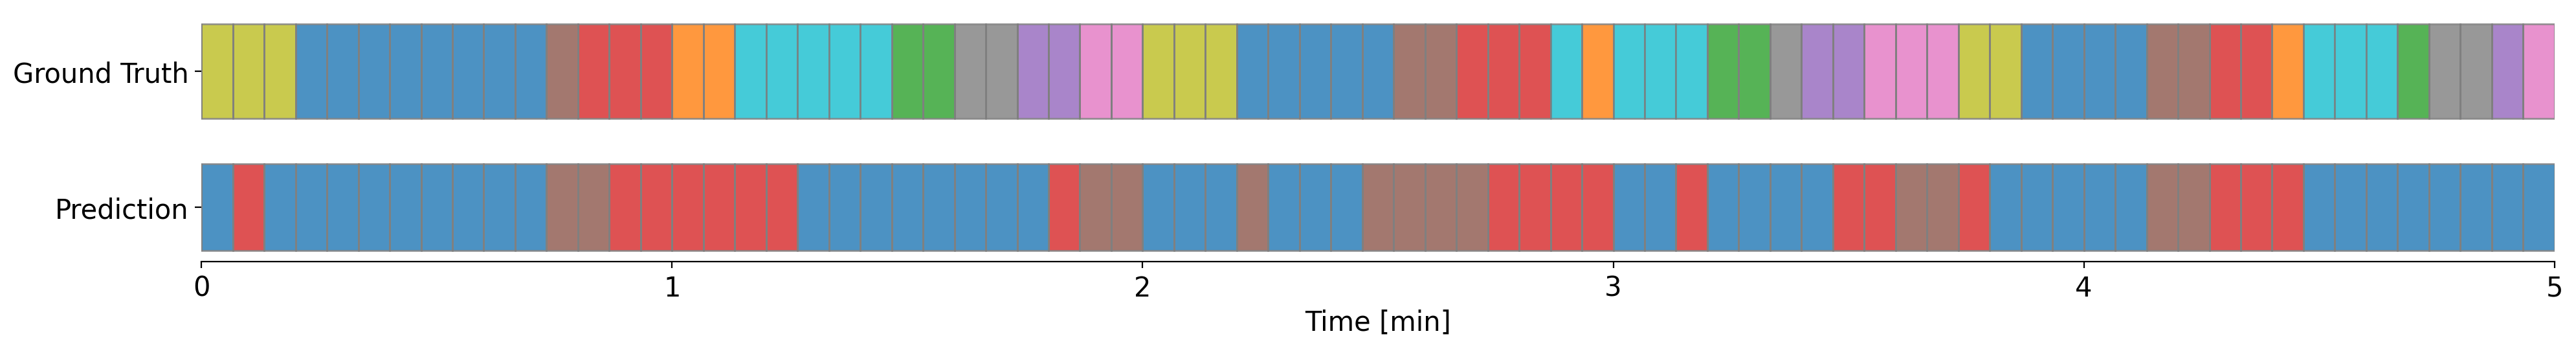

In [ ]:
json_path= "results_loso/1214_3/seed0/T4_cnn-transformer/S0100/U0207.json"


with open(json_path) as f:
    r = json.load(f)

y_true = np.array(r["y_true"])
y_pred = np.array(r["y_pred"])

fig = plot_label_timeline_minute(
    y_true,
    y_pred,
    start_min=0,
    end_min=5,
    num_classes=10,
    stride_sec=4,
    title="U0207 | T4_cnn-transformer"
)

plt.show()


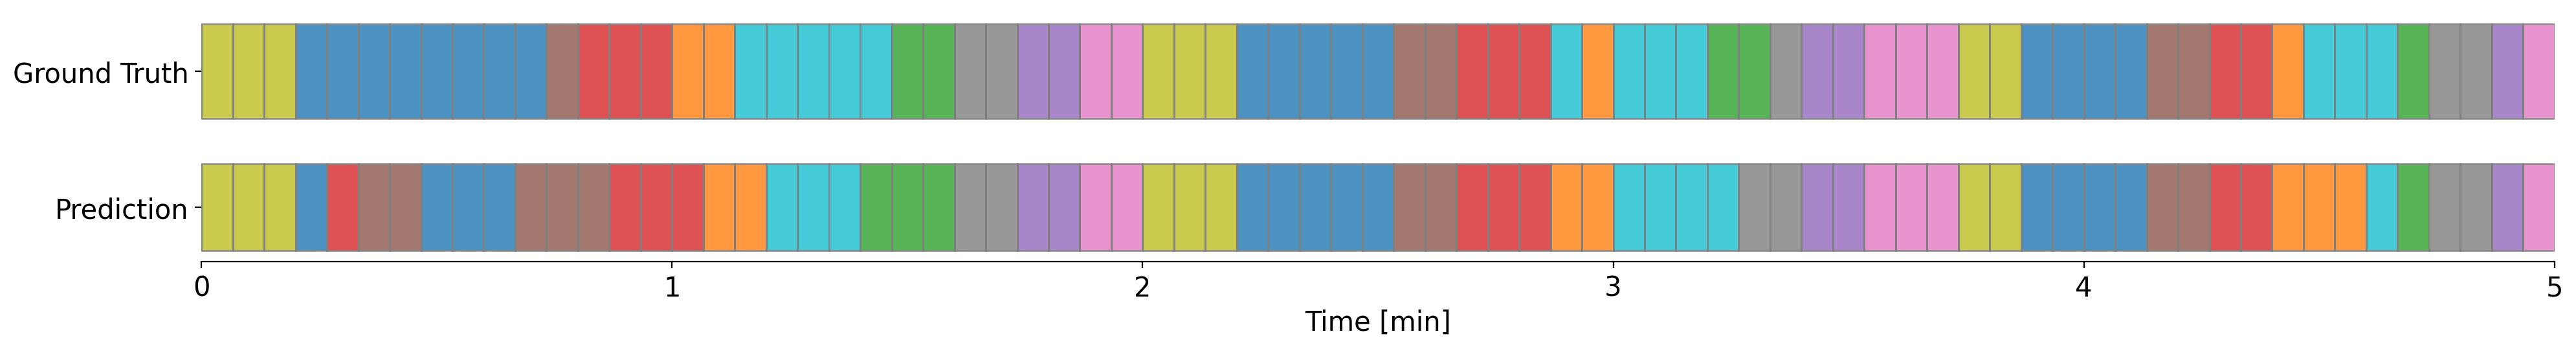

In [ ]:
json_path= "results_loso/1214_3/seed0/T5_precnn-transformer/S0100/U0207.json"


with open(json_path) as f:
    r = json.load(f)

y_true = np.array(r["y_true"])
y_pred = np.array(r["y_pred"])

fig = plot_label_timeline_minute(
    y_true,
    y_pred,
    start_min=0,
    end_min=5,
    num_classes=10,
    stride_sec=4,
    title="U0207 | T5_precnn-transformer"
)
plt.show()

In [ ]:
--

SyntaxError: invalid syntax (3659366440.py, line 1)

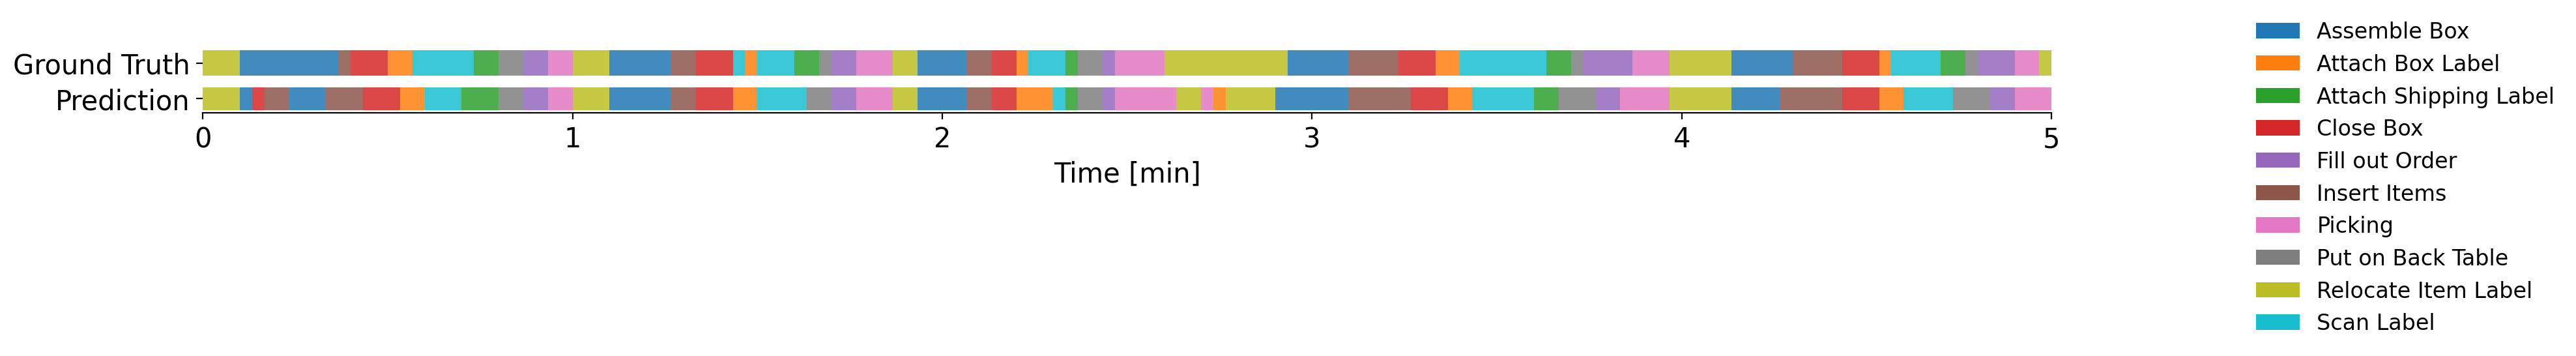

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_label_timeline_minute(
    y_true,
    y_pred,
    start_min,
    end_min,
    class_names,        # ← 手動で与える
    stride_sec=2,
    title=""
):
    """
    y_true, y_pred (2s stride) を
    分単位で指定して GT / Pred ラベル帯を描画
    """

    num_classes = len(class_names)

    # ---- index range ----
    step_per_min = int(60 / stride_sec)   # = 30
    s = start_min * step_per_min
    e = end_min   * step_per_min

    gt = y_true[s:e]
    pred = y_pred[s:e]
    T = len(gt)

    # ---- colormap ----
    cmap = plt.get_cmap("tab10", num_classes)

    fig, ax = plt.subplots(figsize=(20, 2.8), dpi=200)

    # ---- Ground Truth ----
    for c in range(num_classes):
        mask = gt == c
        ax.barh(
            y=1.0,
            width=mask.astype(int),
            left=np.arange(T),
            height=0.35,
            color=cmap(c),
            edgecolor="none",
            alpha=0.85
        )

    # ---- Prediction ----
    for c in range(num_classes):
        mask = pred == c
        ax.barh(
            y=0.5,
            width=mask.astype(int),
            left=np.arange(T),
            height=0.32,
            color=cmap(c),
            edgecolor="none",
            alpha=0.85
        )

    # ---- y axis ----
    ax.set_yticks([0.5, 1.0])
    ax.set_yticklabels(["Prediction", "Ground Truth"], fontsize=15)
    ax.set_xlim(0, T)

    # ---- x axis (minute) ----
    xticks = np.arange(0, T + 1, step_per_min)
    ax.set_xticks(xticks)
    ax.set_xticklabels(start_min + xticks // step_per_min, fontsize=15)
    ax.set_xlabel("Time [min]", fontsize=15)

    # ---- legend (manual labels) ----
    legend_handles = [
        Patch(facecolor=cmap(c), label=class_names[c])
        for c in range(num_classes)
    ]

    ax.legend(
        handles=legend_handles,
        bbox_to_anchor=(1.1, 1.7),
        loc="upper left",
        frameon=False,
        fontsize=12,
        edgecolor="black"
    )

    # ---- clean look ----
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    if title:
        ax.set_title(title, fontsize=12)

    fig.tight_layout()
    return fig


class_names = [
    "Assemble Box",
    "Attach Box Label",
    "Attach Shipping Label",
    "Close Box",
    "Fill out Order",
    "Insert Items",
    "Picking",
    "Put on Back Table",
    "Relocate Item Label",
    "Scan Label",
]

fig = plot_label_timeline_minute(
    y_true,
    y_pred,
    start_min=0,
    end_min=5,
    class_names=class_names
)
